Copyright (C) 2025  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 22/11/2025\
Brief Description:\
This project aims to investigate if sleep and lifestyle factors can \
predict the presence of sleep disorders. The full dataset has 374  
entries. See Technical Specification for more information.

# Random Forest

In [9]:
%matplotlib inline
import pandas as pd
import matplotlib. pyplot as plt
import matplotlib.patches as mp
plt.style.use("seaborn-v0_8-whitegrid")
import numpy as np

import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [5]:
dataset = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")

In [7]:
# Fill any nan values with "None"
dataset["Sleep Disorder"] = dataset["Sleep Disorder"].fillna("None")

# Get features and column stack to get coordinates
stress = dataset["Physical Activity Level"].values
sleepQuality = dataset["Age"].values
coords = np.column_stack((stress, sleepQuality))

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(dataset["Sleep Disorder"])

# Colour mapping for visualization
custom_cmap = ListedColormap([
    "red",   # 0 Insomnia
    "green",     # 1 None
    "blue"     # 2 Sleep apnea
])

# Data is split into training and testing samples, 30% of the data is used for testing and 70% is used for training
X_train, X_test, y_train, y_test = train_test_split(coords, labels, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make prediction
y_pred = model.predict(X_test)

In [104]:
def visualize_classifier(model, X_train, y_train, X_test=None, y_pred=None, cmap=None, xlabel="Feature 1", ylabel="Feature 2", title="Classifier"):

    if cmap is None:
        cmap = ListedColourmap(["red", "green", "blue"])

    fig, ax = plt.subplots(figsize=(8,6))
    
    # Training points = circles
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap=cmap,
               edgecolor='k', alpha=0.5, label='Train')
    
    # Decision boundary
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200),
                         np.linspace(ylim[0], ylim[1], 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, levels=len(np.unique(y_train)), cmap=cmap)
    
    # Test points = triangles
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, s=30, edgecolor='k', marker='^', cmap=cmap, label='Test')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.show()


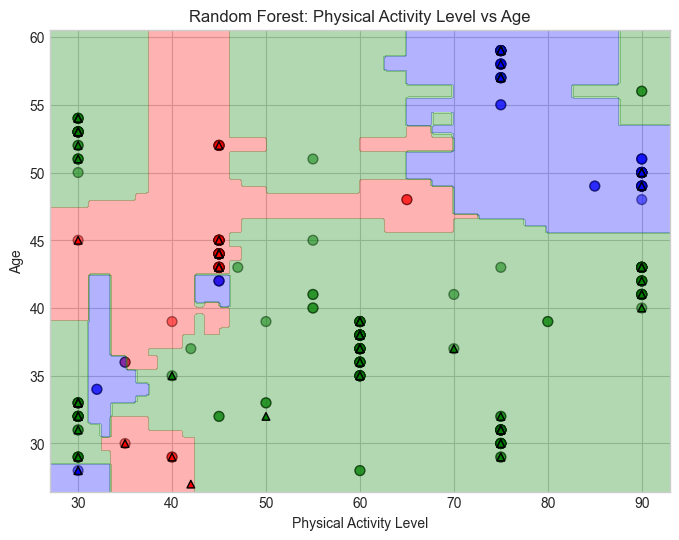

In [102]:
visualize_classifier(model, X_train, y_train, X_test, y_pred, cmap=custom_cmap, xlabel="Physical Activity Level", ylabel="Age", title="Random Forest: Physical Activity Level vs Age")

Confusion Matrix:


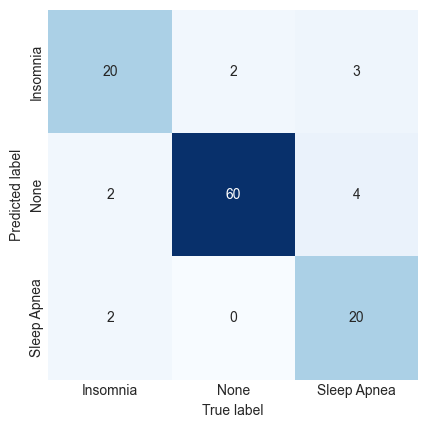

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# Heat map
sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('True label')
plt.ylabel('Predicted label');  

Confusion Matrix:


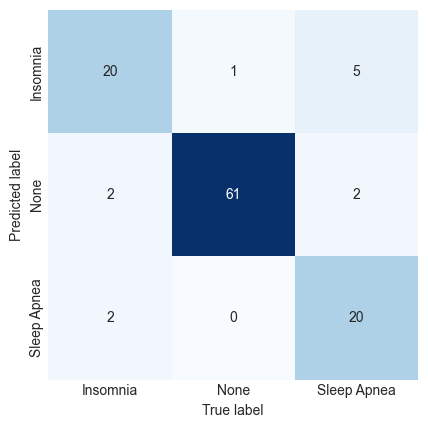

In [11]:
# Get features and column stack to get coordinates
age = dataset["Age"].values
sleepDuration = dataset["Sleep Duration"].values
sleepQuality = dataset["Quality of Sleep"].values
physicalActivity = dataset["Physical Activity Level"].values
stressLevel = dataset["Stress Level"].values
heartRate = dataset["Heart Rate"].values
dailySteps = dataset["Daily Steps"].values
coords = np.column_stack((age, sleepDuration, sleepQuality, physicalActivity, stressLevel, heartRate, dailySteps))

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(dataset["Sleep Disorder"])

# Colour mapping for visualization
custom_cmap = ListedColormap([
    "red",   # 0 Insomnia
    "green",     # 1 None
    "blue"     # 2 Sleep apnea
])

# Data is split into training and testing samples, 30% of the data is used for testing and 70% is used for training
X_train, X_test, y_train, y_test = train_test_split(coords, labels, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make prediction
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# Heat map
sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('True label')
plt.ylabel('Predicted label');  